In [9]:
# ============================================================
# LINEAR REGRESSION BASELINE MODEL
# MSc Data Science Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [10]:
# ------------------------------------------------------------
# 1. Load the feature-engineered modelling dataset
# ------------------------------------------------------------

file_path = "../data/processed/feature_engineered_ev_dataset.csv"

model_df = pd.read_csv(file_path)

In [11]:
# ------------------------------------------------------------
# 2. Inspect the modelling dataset
# ------------------------------------------------------------

print("Dataset Shape:")
print(model_df.shape)

print("\nMissing Values:")
print(model_df.isnull().sum())

Dataset Shape:
(499, 9)

Missing Values:
country                 0
year                    0
ev_sales_share          0
ev_stock                0
ev_stock_share          0
charging_points         0
ev_stock_lag1           0
ev_stock_share_lag1     0
charging_points_lag1    0
dtype: int64


In [12]:
# ------------------------------------------------------------
# 3. Define predictor variables and target variable
# ------------------------------------------------------------

features = [
    'ev_stock_lag1',
    'ev_stock_share_lag1',
    'charging_points_lag1'
]

target = 'ev_sales_share'

In [13]:
# ------------------------------------------------------------
# 4. Create a time-based train and test split
# ------------------------------------------------------------

train_df = model_df[model_df['year'] <= 2022].copy()

test_df = model_df[model_df['year'] >= 2023].copy()


X_train = train_df[features]

y_train = train_df[target]


X_test = test_df[features]

y_test = test_df[target]


print("\nTraining Period:")
print(train_df['year'].min(),"-",train_df['year'].max())

print("\nTesting Period:")
print(test_df['year'].min(),"-",test_df['year'].max())

print("\nTraining Shape:")
print(X_train.shape)

print("\nTesting Shape:")
print(X_test.shape)



Training Period:
2011 - 2022

Testing Period:
2023 - 2024

Training Shape:
(421, 3)

Testing Shape:
(78, 3)


In [14]:
# ------------------------------------------------------------
# 5. Standardise predictor variables
# ------------------------------------------------------------

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)

In [15]:
# ------------------------------------------------------------
# 6. Create the Linear Regression model
# ------------------------------------------------------------

linear_model = LinearRegression()


# ------------------------------------------------------------
# 7. Train the model
# ------------------------------------------------------------

linear_model.fit(
    X_train_scaled,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.28,10.74, 0.1 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.966
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[29.07,20.06, 3.96]"


In [16]:
# ------------------------------------------------------------
# 8. Predict EV Sales Share for the test period
# ------------------------------------------------------------

y_pred_linear = linear_model.predict(
    X_test_scaled
)


# ------------------------------------------------------------
# 9. Evaluate model performance
# ------------------------------------------------------------

linear_r2 = r2_score(
    y_test,
    y_pred_linear
)


linear_mae = mean_absolute_error(
    y_test,
    y_pred_linear
)


linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)


print("\nLinear Regression Results")

print(f"R²   : {linear_r2:.4f}")

print(f"MAE  : {linear_mae:.4f}")

print(f"RMSE : {linear_rmse:.4f}")


Linear Regression Results
R²   : 0.3693
MAE  : 7.6718
RMSE : 16.3651


In [17]:
# ------------------------------------------------------------
# 10. Examine standardised model coefficients
# ------------------------------------------------------------

coefficient_df = pd.DataFrame({

    'Feature': features,

    'Coefficient': linear_model.coef_

})


coefficient_df['Absolute_Coefficient'] = (
    coefficient_df['Coefficient'].abs()
)


coefficient_df = coefficient_df.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)


print("\nStandardised Linear Regression Coefficients:")

print(
    coefficient_df.to_string(
        index=False
    )
)


Standardised Linear Regression Coefficients:
             Feature  Coefficient  Absolute_Coefficient
 ev_stock_share_lag1    10.738885             10.738885
       ev_stock_lag1     0.283237              0.283237
charging_points_lag1     0.097060              0.097060


In [18]:
# ------------------------------------------------------------
# 11. Create prediction results table
# ------------------------------------------------------------

prediction_results = test_df[
    ['country', 'year']
].copy()


prediction_results['Actual_EV_Sales_Share'] = (
    y_test.to_numpy()
)


prediction_results['Predicted_EV_Sales_Share'] = (
    y_pred_linear
)


prediction_results['Absolute_Error'] = np.abs(

    prediction_results['Actual_EV_Sales_Share']

    -

    prediction_results['Predicted_EV_Sales_Share']

)


prediction_results = prediction_results.sort_values(
    by='Absolute_Error',
    ascending=False
)


print("\nLargest Prediction Errors:")

print(
    prediction_results.head(10).to_string(
        index=False
    )
)


Largest Prediction Errors:
    country  year  Actual_EV_Sales_Share  Predicted_EV_Sales_Share  Absolute_Error
     Norway  2024                   92.0                182.255753       90.255753
     Norway  2023                   90.0                158.179898       68.179898
    Iceland  2024                   42.0                109.718014       67.718014
    Finland  2023                   54.0                 29.943979       24.056021
   Portugal  2023                   32.0                 13.112217       18.887783
    Germany  2024                   19.0                 34.365492       15.365492
    Iceland  2023                   71.0                 85.699222       14.699222
      China  2024                   48.0                 62.087161       14.087161
New Zealand  2023                   27.0                 13.681001       13.318999
   Portugal  2024                   33.0                 19.755394       13.244606


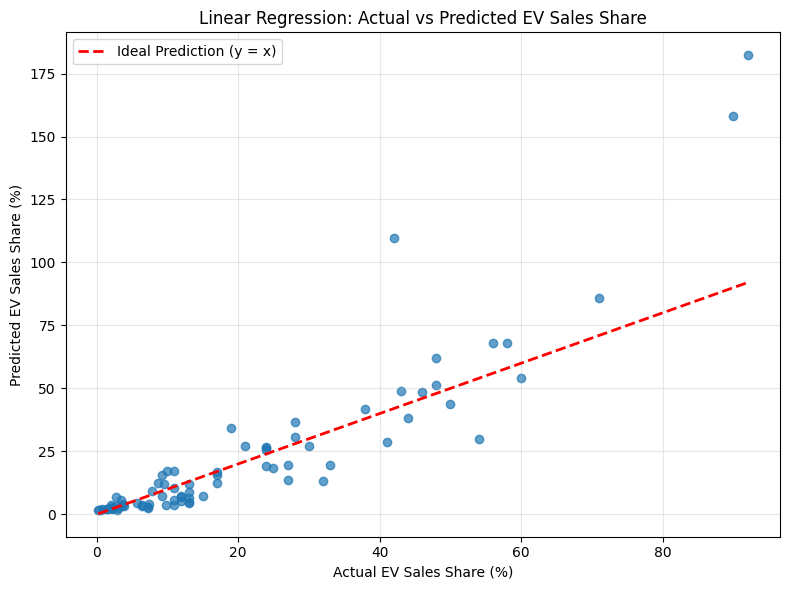

In [19]:
# ------------------------------------------------------------
# 12. Actual vs Predicted plot
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)


plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.7
)


plt.plot(

    [
        y_test.min(),
        y_test.max()
    ],

    [
        y_test.min(),
        y_test.max()
    ],

    'r--',

    linewidth=2,

    label='Ideal Prediction (y = x)'

)


plt.xlabel(
    'Actual EV Sales Share (%)'
)

plt.ylabel(
    'Predicted EV Sales Share (%)'
)

plt.title(
    'Linear Regression: Actual vs Predicted EV Sales Share'
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()